In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    precision_recall_curve, roc_curve, auc,
    precision_recall_fscore_support
)


In [2]:

try:
    if_df = pd.read_csv("../data/processed/if_predictions.csv")
except FileNotFoundError:
    if_df = None

try:
    ae_df = pd.read_csv("../data/processed/autoencoder_predictions.csv")
except FileNotFoundError:
    ae_df = None

try:
    tf_df = pd.read_csv("../data/processed/transformer_predictions.csv")
except FileNotFoundError:
    tf_df = None

print("Loaded files:")
print({
    "Isolation Forest": if_df is not None,
    "Autoencoder": ae_df is not None,
    "Transformer": tf_df is not None
})


Loaded files:
{'Isolation Forest': True, 'Autoencoder': True, 'Transformer': True}


In [3]:
def compute_metrics(df, score_col, model_name):
    """Compute Precision, Recall, F1, PR-AUC, ROC-AUC."""
    if df is None:
        return None
    y_true = df["actual"]
    y_score = df[score_col]

    # Find best threshold for F1
    best_f1, best_t = 0, 0
    for t in np.linspace(0.1, 0.9, 17):
        preds = (y_score >= t).astype(int)
        p, r, f1, _ = precision_recall_fscore_support(y_true, preds, average="binary", zero_division=0)
        if f1 > best_f1:
            best_f1, best_t, best_p, best_r = f1, t, p, r

    prec, rec, _ = precision_recall_curve(y_true, y_score)
    fpr, tpr, _  = roc_curve(y_true, y_score)
    pr_auc  = auc(rec, prec)
    roc_auc = auc(fpr, tpr)

    return {
        "Model": model_name,
        "Precision": best_p,
        "Recall": best_r,
        "F1": best_f1,
        "PR-AUC": pr_auc,
        "ROC-AUC": roc_auc,
        "Best Threshold": best_t
    }


In [4]:
results = []

if if_df is not None:
    results.append(compute_metrics(if_df, "anomaly_score", "Isolation Forest"))
if ae_df is not None:
    results.append(compute_metrics(ae_df, "anomaly_score", "Autoencoder"))
if tf_df is not None:
    results.append(compute_metrics(tf_df, "prob", "Transformer"))

metrics_df = pd.DataFrame(results)
metrics_df


,Model,Precision,Recall,F1,PR-AUC,ROC-AUC,Best Threshold
0,Isolation Forest,0.550607,1.000000,0.710183,0.525083,0.474314,0.10
1,Autoencoder,1.000000,0.000662,0.001323,0.969520,0.967474,0.10
2,Transformer,0.780274,0.666593,0.718967,0.835948,0.744653,0.35


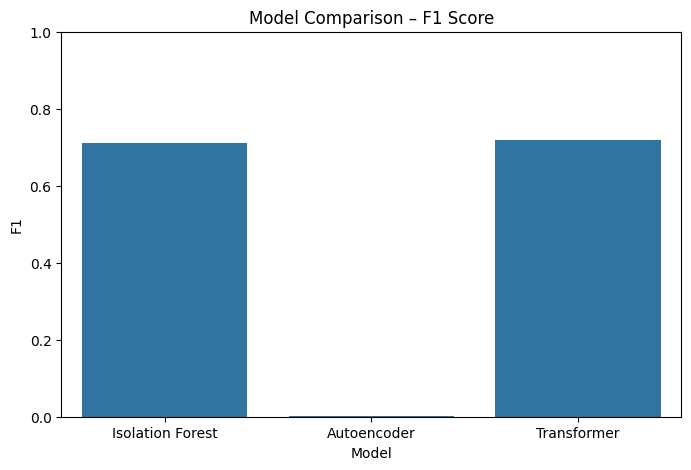

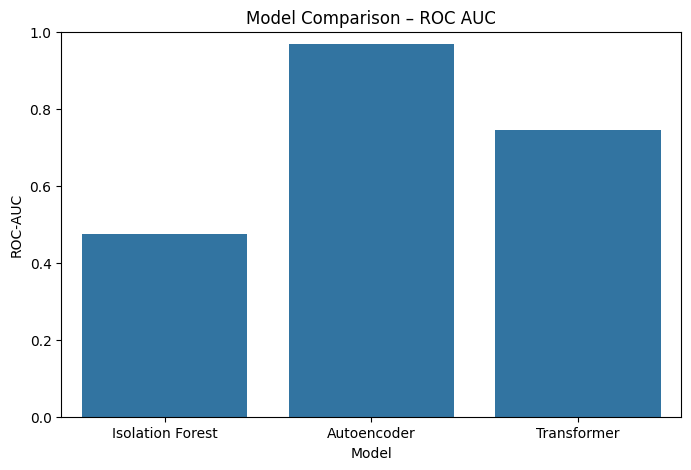

In [5]:
plt.figure(figsize=(8,5))
sns.barplot(x="Model", y="F1", data=metrics_df)
plt.title("Model Comparison – F1 Score")
plt.ylim(0, 1)
plt.show()

plt.figure(figsize=(8,5))
sns.barplot(x="Model", y="ROC-AUC", data=metrics_df)
plt.title("Model Comparison – ROC AUC")
plt.ylim(0, 1)
plt.show()


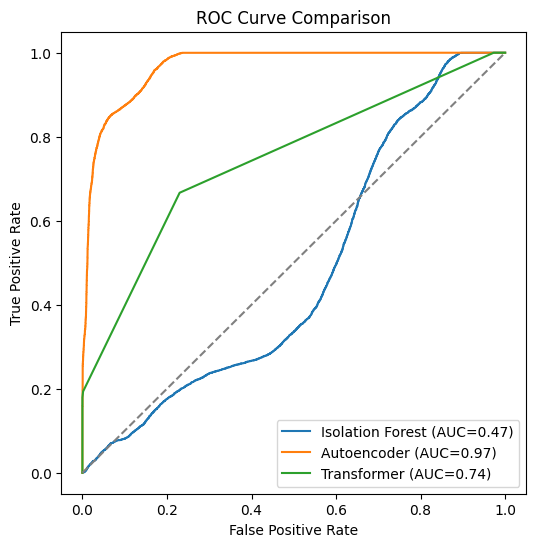

In [6]:
plt.figure(figsize=(6,6))
for df_, name, col in [
    (if_df, "Isolation Forest", "anomaly_score"),
    (ae_df, "Autoencoder", "anomaly_score"),
    (tf_df, "Transformer", "prob"),
]:
    if df_ is None: continue
    y_true = df_["actual"]
    y_score = df_[col]
    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc:.2f})")

plt.plot([0,1],[0,1],'--',color='gray')
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


In [7]:
metrics_df.to_csv("../data/processed/model_comparison_summary.csv", index=False)
print("✅ Comparison summary saved at data/processed/model_comparison_summary.csv")


✅ Comparison summary saved at data/processed/model_comparison_summary.csv
